In [2]:
import matplotlib.pyplot as plt
import cv2
import os
import pickle
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import seaborn as sns
import sklearn
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (EarlyStopping,ModelCheckpoint,ReduceLROnPlateau)
from sklearn.metrics import (confusion_matrix,classification_report,ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings("ignore")

In [3]:
dataset_path = r"/Users/Aashi_Dixit/Desktop/DS_SUMMER_TRAINING/MAIN PROJECT/CNN_dataset/Air Pollution Image Dataset/Combined_Dataset/IND_and_NEP"

In [4]:
print(os.listdir(dataset_path))

['b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'a_Good', 'f_Severe', 'e_Very_Unhealthy']


In [5]:
for folder in os.listdir(dataset_path):
    path = os.path.join(dataset_path, folder)
    print(folder, len(os.listdir(path)))

b_Moderate 1573
c_Unhealthy_for_Sensitive_Groups 2863
d_Unhealthy 2622
a_Good 1541
f_Severe 1447
e_Very_Unhealthy 2194


In [6]:
IMG_SIZE = (160,160)

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=64
)

Found 12240 files belonging to 6 classes.
Using 9792 files for training.


In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 12240 files belonging to 6 classes.
Using 2448 files for validation.


In [9]:
class_names = train_ds.class_names

print(class_names)

['a_Good', 'b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'e_Very_Unhealthy', 'f_Severe']


In [10]:
with open("class_names.pkl","wb") as f:
    pickle.dump(class_names,f)

2026-07-24 01:42:46.240211: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


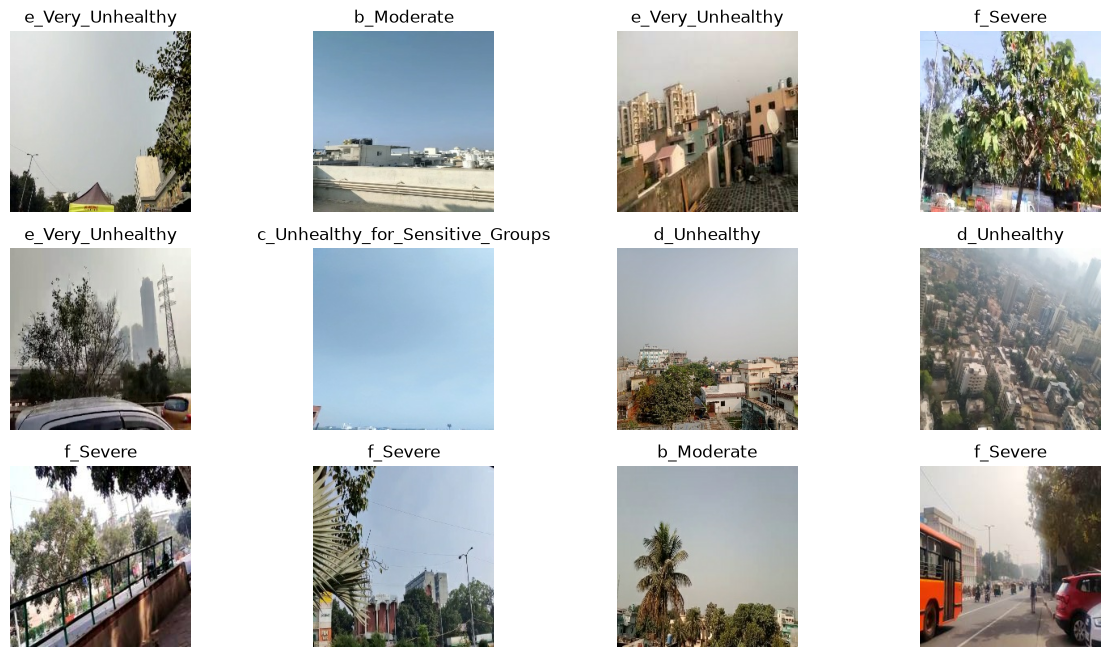

In [11]:
plt.figure(figsize=(15,8))

for images, labels in train_ds.take(1):

    for i in range(12):

        ax=plt.subplot(3,4,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [13]:
normalization_layer = layers.Rescaling(1./255)

In [14]:
train_ds = train_ds.map(
    lambda x,y:(normalization_layer(x),y)
)

val_ds = val_ds.map(
    lambda x,y:(normalization_layer(x),y)
)

In [15]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [16]:
for image,label in train_ds.take(1):

    first_image=image[0]

    break

2026-07-24 01:43:06.699546: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:17: Filling up shuffle buffer (this may take a while): 150 of 1000
2026-07-24 01:43:16.737704: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:17: Filling up shuffle buffer (this may take a while): 238 of 1000
2026-07-24 01:43:26.164765: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.02304852..1.0072883].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00817287..1.0459447].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0078040957..1.021733].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0495211].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0390627].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0627775].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.070447].
Clipping inpu

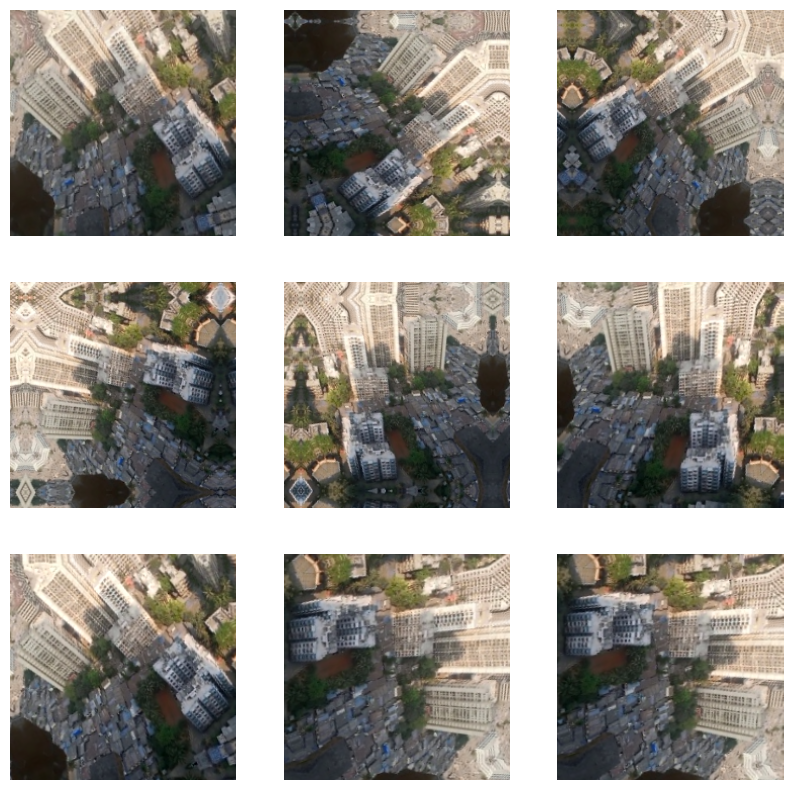

In [17]:
plt.figure(figsize=(10,10))

for i in range(9):

    ax=plt.subplot(3,3,i+1)

    aug=data_augmentation(tf.expand_dims(first_image,0))

    plt.imshow(aug[0])

    plt.axis("off")

In [18]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [19]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs, outputs)

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),

    ReduceLROnPlateau(
        factor=0.2,
        patience=2
    ),

    ModelCheckpoint(
        "best_cnn.keras",
        save_best_only=True
    )
]

In [22]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2,
    callbacks=callbacks
)

In [ ]:
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Accuracy :", accuracy)
print("Loss :", loss)

In [ ]:
y_true = np.concatenate([y for _, y in val_ds])

y_pred = np.argmax(model.predict(val_ds), axis=1)

In [ ]:
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(cmap="Blues")

plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

In [ ]:
model.save("cnn_model.keras")

In [ ]:
from tensorflow.keras.preprocessing import image

In [ ]:
def predict_image(img_path):

    img = image.load_img(img_path, target_size=(224,224))

    img = image.img_to_array(img) / 255.0

    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)

    idx = np.argmax(pred)

    confidence = np.max(pred)

    print("Predicted Class :", class_names[idx])

    print("Confidence :", round(confidence*100,2),"%")

In [ ]:
predict_image("sample.jpg")

In [ ]:
aqi_info = pd.read_csv("IND_and_Nep_AQI_Dataset.csv")

summary = aqi_info.groupby("AQI_Class")[
    ["AQI", "PM2.5", "PM10", "CO", "NO2", "SO2", "O3"]
].mean()

summary.to_csv("aqi_summary.csv")

In [ ]:
aqi_df = pd.read_csv(
    r"CNN_dataset/Air Pollution Image Dataset/Combined_Dataset/IND_and_Nep_AQI_Dataset.csv"
)

summary = (
    aqi_df
    .groupby("AQI_Class")[["AQI","PM2.5","PM10","CO","SO2","NO2","O3"]]
    .mean()
    .round(2)
)

summary

In [ ]:
summary.to_csv("aqi_summary.csv")

In [ ]:
summary

In [ ]:
health_info = {
    "a_Good":
        "Air quality is good. Safe for outdoor activities.",

    "b_Moderate":
        "Acceptable. Sensitive people should reduce prolonged exposure.",

    "c_Unhealthy_for_Sensitive_Groups":
        "Children and elderly should reduce outdoor activities.",

    "d_Unhealthy":
        "Reduce prolonged outdoor exposure.",

    "e_Very_Unhealthy":
        "Wear an N95 mask. Stay indoors if possible.",

    "f_Severe":
        "Avoid going outdoors. Health emergency conditions."
}

In [ ]:
pollution_source = {

"a_Good":"Minimal pollution",

"b_Moderate":"Light vehicle emissions",

"c_Unhealthy_for_Sensitive_Groups":"Traffic and road dust",

"d_Unhealthy":"Traffic + industrial emissions",

"e_Very_Unhealthy":"Construction + factories",

"f_Severe":"Industrial smoke, biomass burning, fire"
}

In [ ]:
travel = {

"a_Good":"Excellent for outdoor exercise.",

"b_Moderate":"Suitable for walking and cycling.",

"c_Unhealthy_for_Sensitive_Groups":"Sensitive people should avoid prolonged exercise.",

"d_Unhealthy":"Outdoor exercise not recommended.",

"e_Very_Unhealthy":"Stay indoors if possible.",

"f_Severe":"Avoid all outdoor activities."
}